In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="XufIgI94wgR9n3u7GKJT")
project = rf.workspace("abiyamf").project("plant-pathology-2021-object-detection-j1jvh-4mznp")
version = project.version(2)
dataset = version.download("yolov12", location="dataset_k-shot/healthy_rust")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset_k-shot/healthy_rust in yolov12:: 100%|██████████| 1012/1012 [00:00<00:00, 2595.77it/s]


In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="XufIgI94wgR9n3u7GKJT")
project = rf.workspace("abiyamf").project("plant-pathology-2021-object-detection-j1jvh-4mznp")
version = project.version(2)
dataset = version.download("coco", location="dataset_k-shot/faster-r-cnn")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset_k-shot/faster-r-cnn in coco:: 100%|██████████| 508/508 [00:00<00:00, 2634.58it/s]


In [7]:
from roboflow import Roboflow
rf = Roboflow(api_key="XufIgI94wgR9n3u7GKJT")
project = rf.workspace("abiyamf").project("plant-pathology-2021-object-detection-j1jvh-4mznp")
version = project.version(3)
dataset = version.download("coco", location="dataset_k-shot/healthy")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset_k-shot/healthy in coco:: 100%|██████████| 258/258 [00:00<00:00, 2307.82it/s]


In [2]:
import os
import glob
import random

dataset_path = "dataset_k-shot/healthy_rust"
splits_to_filter = ['train', 'valid']
# Jumlah sampel healthy yang ingin dipertahankan agar model tidak lupa
keep_count = {"train": 25, "valid": 5} 

def clean_with_memory(path):
    for split in splits_to_filter:
        img_dir = os.path.join(path, split, 'images')
        lbl_dir = os.path.join(path, split, 'labels')
        
        # Ambil semua file healthy
        all_healthy = glob.glob(os.path.join(img_dir, "*healthy*"))
        
        if len(all_healthy) > keep_count[split]:
            # Acak dan pilih mana yang akan dihapus
            random.shuffle(all_healthy)
            to_delete = all_healthy[keep_count[split]:] # Sisakan sebanyak keep_count
            
            print(f"[{split.upper()}] Menyisakan {keep_count[split]} file, menghapus {len(to_delete)} file.")
            
            for img_path in to_delete:
                # Hapus Gambar
                os.remove(img_path)
                # Hapus Label
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
                if os.path.exists(lbl_path):
                    os.remove(lbl_path)

clean_with_memory(dataset_path)

[TRAIN] Menyisakan 25 file, menghapus 150 file.
[VALID] Menyisakan 5 file, menghapus 20 file.


# Train

In [2]:
from ultralytics import YOLO, settings
settings.update({"mlflow": False})

In [2]:
for k in range(40,51,5):
    model_novel = YOLO("model_k-shot/best.pt")
    train = model_novel.train(data=f"few_shot_experiments/{k}-shot.yaml", epochs=50, imgsz=640, project="training_k-shot_results/train", name=f"novel_{k}-shot", exist_ok=True)
    validation = model_novel.val(data=f"few_shot_experiments/{k}-shot.yaml", imgsz=640, project="training_k-shot_results/valid", split="test", name=f"novel_{k}-shot", exist_ok=True)

for k in range(5,51,5):
    model_yaml = YOLO("yolo12n.yaml")
    train = model_yaml.train(data=f"few_shot_experiments/{k}-shot.yaml", epochs=50, imgsz=640, project="training_k-shot_results/train", name=f"yaml_{k}-shot", exist_ok=True)
    validation = model_yaml.val(data=f"few_shot_experiments/{k}-shot.yaml", imgsz=640, project="training_k-shot_results/valid", split="test", name=f"yaml_{k}-shot", exist_ok=True)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/40-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=model_k-shot/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=novel_

In [4]:
for k in range(5,51,5):
    model_yaml = YOLO("yolo12n.pt")
    train = model_yaml.train(data=f"few_shot_experiments/{k}-shot.yaml", epochs=50, imgsz=640, project="training_k-shot_results/train", name=f"normal_{k}-shot", exist_ok=True)
    validation = model_yaml.val(data=f"few_shot_experiments/{k}-shot.yaml", imgsz=640, project="training_k-shot_results/valid", split="test", name=f"normal_{k}-shot", exist_ok=True)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=normal_5-shot, nb

In [3]:
for k in range(5,51,5):
    model_yaml = YOLO("yolo12n.pt")
    num_freeze = int(len(model_yaml.model.model) * 0.90)
    train = model_yaml.train(data=f"few_shot_experiments/{k}-shot.yaml", epochs=50, imgsz=640, project="training_k-shot_results/train", name=f"normal_freeze_{k}-shot", exist_ok=True, freeze=num_freeze)
    validation = model_yaml.val(data=f"few_shot_experiments/{k}-shot.yaml", imgsz=640, project="training_k-shot_results/valid", split="test", name=f"normal_freeze_{k}-shot", exist_ok=True)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=19, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=normal_freeze_5-sho

In [ ]:
for k in range(5,51,5):
    model = YOLO("model_k-shot/best.pt")
    num_freeze = int(len(model.model.model) * 0.90)
    train = model_yaml.train(data=f"few_shot_experiments/{k}-shot.yaml", epochs=50, imgsz=640, project="training_k-shot_results/train", name=f"novel_freeze_{k}-shot", exist_ok=True, freeze=num_freeze)
    validation = model_yaml.val(data=f"few_shot_experiments/{k}-shot.yaml", imgsz=640, project="training_k-shot_results/valid", split="test", name=f"novel_freeze_{k}-shot", exist_ok=True)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=19, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=model_k-shot/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=novel_fre

Mengekstrak data...


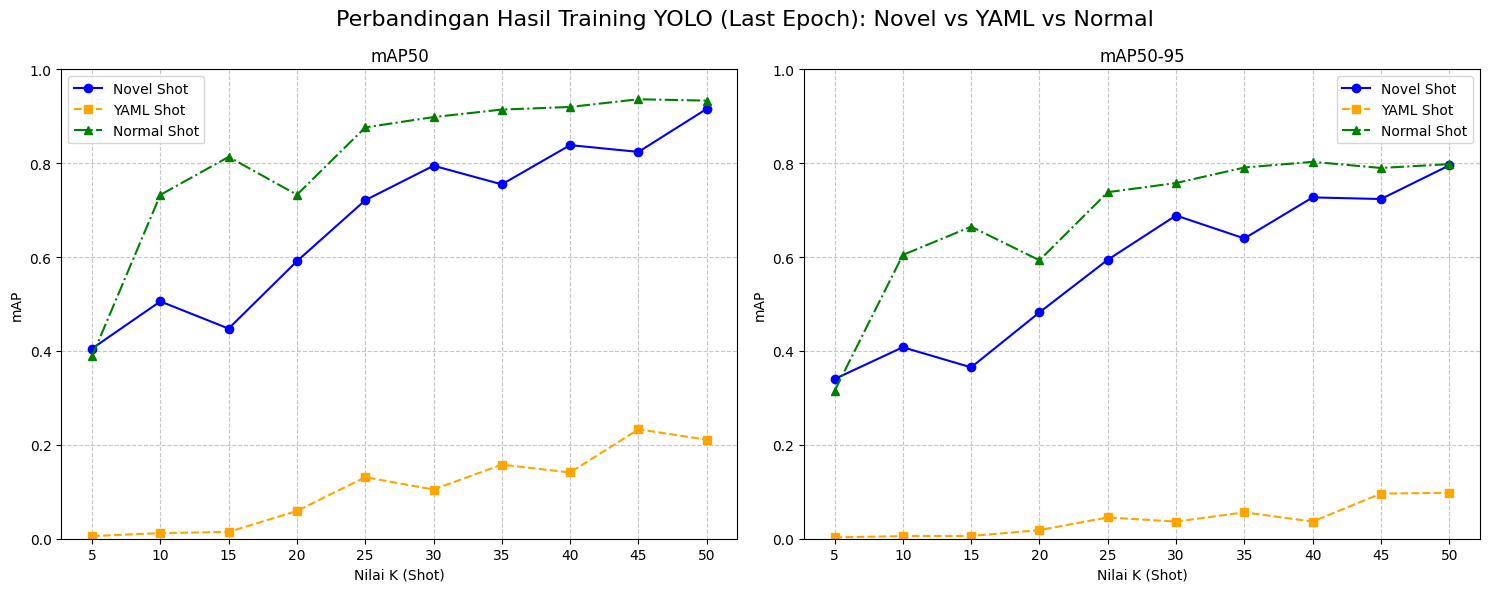

In [5]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt

def extract_yolo_metrics(base_path_template, k_range):
    """
    Mengekstrak data mAP50 dan mAP50-95 dari file results.csv YOLO
    berdasarkan pola folder dan range K.
    """
    k_found = []
    map50_values = []
    map95_values = []

    for k in k_range:
        # Format path sesuai request
        folder_path = base_path_template.format(k=k)
        csv_file = os.path.join(folder_path, 'results.csv')

        if os.path.exists(csv_file):
            try:
                # Baca CSV
                df = pd.read_csv(csv_file)
                
                # Membersihkan nama kolom (YOLO sering memiliki spasi di nama kolom csv)
                df.columns = df.columns.str.strip()
                
                # Pastikan kolom yang dicari ada
                if 'metrics/mAP50(B)' in df.columns and 'metrics/mAP50-95(B)' in df.columns:
                    # Ambil baris terakhir (Last Epoch)
                    last_epoch = df.iloc[-1]
                    
                    k_found.append(k)
                    map50_values.append(last_epoch['metrics/mAP50(B)'])
                    map95_values.append(last_epoch['metrics/mAP50-95(B)'])
                else:
                    print(f"Warning: Kolom metrics tidak ditemukan di {csv_file}")
            except Exception as e:
                print(f"Error membaca file {csv_file}: {e}")
        else:
            # Uncomment baris di bawah ini jika ingin melihat log file yang hilang
            # print(f"Info: File tidak ditemukan untuk K={k} di path: {csv_file}")
            pass

    return k_found, map50_values, map95_values

# --- Konfigurasi ---
# Range K: 5 sampai 50 dengan kelipatan 5
k_values = range(5, 55, 5)

# Template path (sesuaikan jika root folder berbeda)
path_novel = "training_k-shot_results/train/novel_{k}-shot"
path_yaml = "training_k-shot_results/train/yaml_{k}-shot"
path_normal = "training_k-shot_results/train/normal_{k}-shot" # <-- Tambahan Path Normal

# --- Ekstraksi Data ---
print("Mengekstrak data...")
k_novel, map50_novel, map95_novel = extract_yolo_metrics(path_novel, k_values)
k_yaml, map50_yaml, map95_yaml = extract_yolo_metrics(path_yaml, k_values)
k_normal, map50_normal, map95_normal = extract_yolo_metrics(path_normal, k_values) # <-- Ekstraksi Normal

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Judul Utama
fig.suptitle('Perbandingan Hasil Training YOLO (Last Epoch): Novel vs YAML vs Normal', fontsize=16)

# === Plot 1: mAP50 ===
# 1. Novel (Biru, Bulat)
if k_novel:
    ax1.plot(k_novel, map50_novel, marker='o', linestyle='-', label='Novel Shot', color='blue')
# 2. YAML (Oranye, Kotak)
if k_yaml:
    ax1.plot(k_yaml, map50_yaml, marker='s', linestyle='--', label='YAML Shot', color='orange')
# 3. Normal (Hijau, Segitiga) <-- Tambahan Plot
if k_normal:
    ax1.plot(k_normal, map50_normal, marker='^', linestyle='-.', label='Normal Shot', color='green')

ax1.set_title('mAP50')
ax1.set_xlabel('Nilai K (Shot)')
ax1.set_ylabel('mAP')
ax1.set_ylim(0.0, 1.0)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# === Plot 2: mAP50-95 ===
# 1. Novel (Biru, Bulat)
if k_novel:
    ax2.plot(k_novel, map95_novel, marker='o', linestyle='-', label='Novel Shot', color='blue')
# 2. YAML (Oranye, Kotak)
if k_yaml:
    ax2.plot(k_yaml, map95_yaml, marker='s', linestyle='--', label='YAML Shot', color='orange')
# 3. Normal (Hijau, Segitiga) <-- Tambahan Plot
if k_normal:
    ax2.plot(k_normal, map95_normal, marker='^', linestyle='-.', label='Normal Shot', color='green')

ax2.set_title('mAP50-95')
ax2.set_xlabel('Nilai K (Shot)')
ax2.set_ylabel('mAP')
ax2.set_ylim(0.0, 1.0)
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Mulai mengekstrak data...
  -> Novel Shot: Ditemukan 10 data points.
  -> YAML Shot: Ditemukan 10 data points.
  -> Normal Shot: Ditemukan 10 data points.
  -> Normal Freeze: Ditemukan 10 data points.
  -> Novel Freeze: Ditemukan 10 data points.


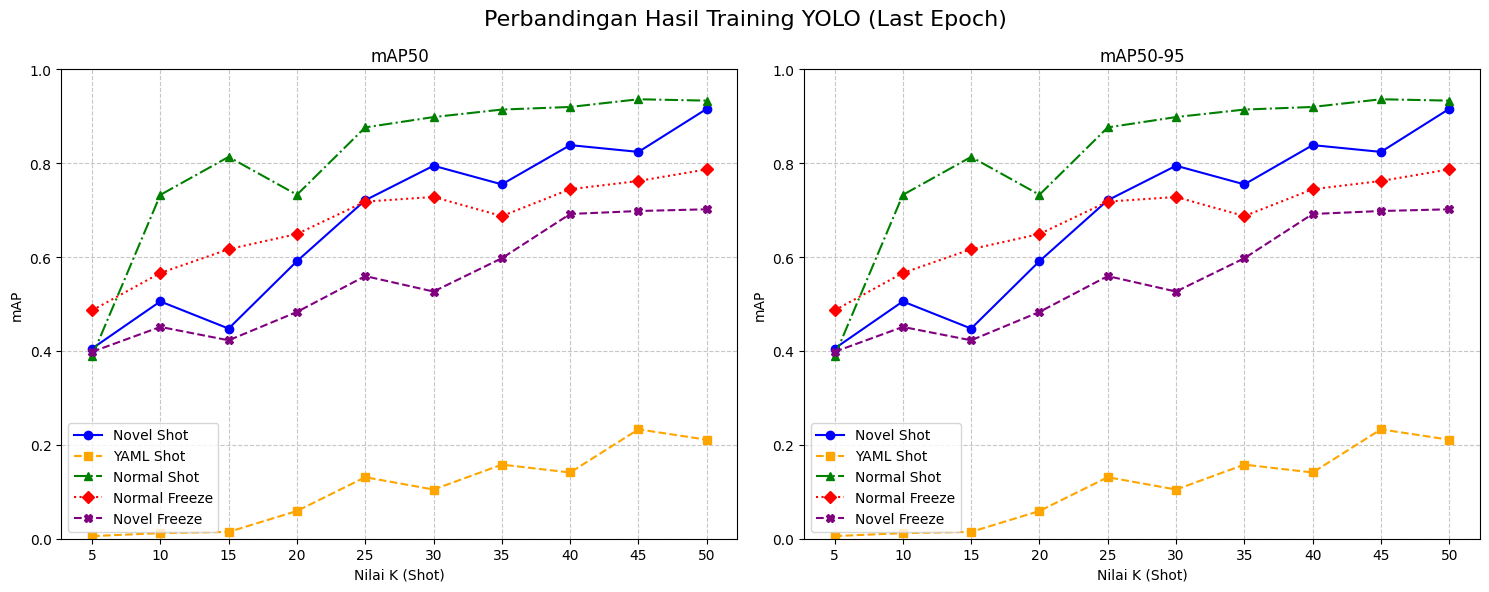

In [5]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- FUNGSI EKSTRAKSI (TIDAK PERLU DIUBAH) ---
def extract_yolo_metrics(base_path_template, k_range):
    """
    Mengekstrak data mAP50 dan mAP50-95 dari file results.csv YOLO.
    """
    k_found = []
    map50_values = []
    map95_values = []

    for k in k_range:
        folder_path = base_path_template.format(k=k)
        csv_file = os.path.join(folder_path, 'results.csv')

        if os.path.exists(csv_file):
            try:
                df = pd.read_csv(csv_file)
                df.columns = df.columns.str.strip() # Bersihkan spasi nama kolom
                
                if 'metrics/mAP50(B)' in df.columns and 'metrics/mAP50-95(B)' in df.columns:
                    last_epoch = df.iloc[-1]
                    k_found.append(k)
                    map50_values.append(last_epoch['metrics/mAP50(B)'])
                    map95_values.append(last_epoch['metrics/mAP50-95(B)'])
            except Exception as e:
                print(f"Error reading {csv_file}: {e}")
    
    return k_found, map50_values, map95_values

# ==========================================
# BAGIAN KONFIGURASI (EDIT DI SINI SAJA)
# ==========================================

# Range K
k_values = range(5, 55, 5)

# Daftar Eksperimen. Cukup tambah dictionary baru ke dalam list ini.
experiments_config = [
    {
        "label": "Novel Shot",
        "path": "training_k-shot_results/train/novel_{k}-shot",
        "color": "blue",
        "marker": "o",
        "linestyle": "-"
    },
    {
        "label": "YAML Shot",
        "path": "training_k-shot_results/train/yaml_{k}-shot",
        "color": "orange",
        "marker": "s",
        "linestyle": "--"
    },
    {
        "label": "Normal Shot",
        "path": "training_k-shot_results/train/normal_{k}-shot",
        "color": "green",
        "marker": "^",
        "linestyle": "-."
    },
    # --- CONTOH MENAMBAHKAN FOLDER BARU ---
    {
        "label": "Normal Freeze",   # Nama di Legenda
        "path": "training_k-shot_results/train/normal_freeze_{k}-shot", # Path folder
        "color": "red",             # Warna Garis
        "marker": "D",              # Bentuk Marker (D=Diamond)
        "linestyle": ":"            # Gaya Garis (: = dotted)
    },
    {
        "label": "Novel Freeze",   # Nama di Legenda
        "path": "training_k-shot_results/train/novel_freeze_{k}-shot", # Path folder
        "color": "purple",             # Warna Garis
        "marker": "X",              # Bentuk Marker (D=Diamond)
        "linestyle": "--"            # Gaya Garis (: = dotted)
    }
]
# ==========================================
# PROSES EKSEKUSI (OTOMATIS)
# ==========================================

# 1. Loop untuk Ekstraksi Data
print("Mulai mengekstrak data...")
results_data = []

for config in experiments_config:
    k_res, map50_res, map95_res = extract_yolo_metrics(config["path"], k_values)
    
    # Simpan hasil ekstraksi ke dalam dictionary sementara
    results_data.append({
        "config": config,
        "k": k_res,
        "map50": map50_res,
        "map95": map50_res
    })
    print(f"  -> {config['label']}: Ditemukan {len(k_res)} data points.")

# 2. Loop untuk Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan Hasil Training YOLO (Last Epoch)', fontsize=16)

for item in results_data:
    # Ambil konfigurasi dan data
    cfg = item["config"]
    k = item["k"]
    map50 = item["map50"]
    map95 = item["map95"]
    
    # Hanya plot jika data ditemukan
    if k:
        # Plot ke Axis 1 (mAP50)
        ax1.plot(k, map50, 
                 label=cfg["label"], 
                 color=cfg["color"], 
                 marker=cfg["marker"], 
                 linestyle=cfg["linestyle"])
        
        # Plot ke Axis 2 (mAP50-95)
        ax2.plot(k, map95, 
                 label=cfg["label"], 
                 color=cfg["color"], 
                 marker=cfg["marker"], 
                 linestyle=cfg["linestyle"])

# Konfigurasi Tampilan Grafik (Kosmetik)
for ax in [ax1, ax2]:
    ax.set_xlabel('Nilai K (Shot)')
    ax.set_ylabel('mAP')
    ax.set_ylim(0.0, 1.0)
    ax.set_xticks(k_values)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

ax1.set_title('mAP50')
ax2.set_title('mAP50-95')

plt.tight_layout()
plt.show()

# Batas

In [2]:
import os
import shutil
import random
import yaml
from pathlib import Path

# --- KONFIGURASI ---
base_path = Path("dataset_k-shot/healthy_rust")
output_base = Path("few_shot_experiments")
shots = range(5, 55, 5) # 5, 10, 15... 50
classes = ['healthy', 'rust']

def setup_few_shot():
    for k in shots:
        shot_dir = output_base / f"{k}-shot"
        img_dest = shot_dir / "train" / "images"
        lbl_dest = shot_dir / "train" / "labels"
        os.makedirs(img_dest, exist_ok=True)
        os.makedirs(lbl_dest, exist_ok=True)

        for cls in classes:
            # Ambil semua gambar asli dari folder train
            all_imgs = list((base_path / "train" / "images").glob(f"*{cls}*"))
            # Ambil K sampel acak
            sampled = random.sample(all_imgs, min(k, len(all_imgs)))
            
            for img_path in sampled:
                # Copy Image
                shutil.copy(img_path, img_dest / img_path.name)
                # Copy Label
                lbl_name = img_path.stem + ".txt"
                shutil.copy(base_path / "train" / "labels" / lbl_name, lbl_dest / lbl_name)

        # Buat file data.yaml
        yaml_data = {
            'train': str((shot_dir / "train" / "images").absolute()),
            'val': str((base_path / "valid" / "images").absolute()),
            'test': str((base_path / "test" / "images").absolute()),
            'nc': 2,
            'names': ['healthy', 'rust']
        }
        
        with open(output_base / f"{k}-shot.yaml", 'w') as f:
            yaml.dump(yaml_data, f)
            
    print(f"Dataset few-shot selesai dibuat di folder: {output_base}")

setup_few_shot()

Dataset few-shot selesai dibuat di folder: few_shot_experiments


In [5]:
from ultralytics import YOLO

for k in range(5, 55, 5):
    print(f"\n--- Memulai Training: {k}-Shot dengan Base Class ---")
    # Menggunakan model yang sudah dilatih sebelumnya (best.pt)
    model = YOLO("model_k-shot/best.pt")
    
    # Training
    model.train(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        epochs=50, 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"base_class_{k}_shot",
    )
    
    # Validation menggunakan split TEST
    model.val(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"base_class_{k}_shot_val",
        split="test"
    )


--- Memulai Training: 5-Shot dengan Base Class ---
New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=model_k-shot/best.pt, moment

FileNotFoundError: [34m[1mtrain: [0mError loading data from C:\Users\abiyamf\Documents\Code Program\Thesis\random_experiment\few_shot_experiments\5-shot\images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [2]:
from ultralytics import YOLO

for k in range(5, 55, 5):
    print(f"\n--- Memulai Training: {k}-Shot dari Scratch ---")
    # Menggunakan model dasar (yolov12n.pt) tanpa pengetahuan daun
    model = YOLO("yolo12n.pt") 
    
    # Training
    model.train(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        epochs=50, 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"scratch_{k}_shot"
    )
    
    # Validation menggunakan split TEST
    model.val(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"scratch_{k}_shot_val",
        split="test"
    )


--- Memulai Training: 5-Shot dari Scratch ---
New https://pypi.org/project/ultralytics/8.3.242 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosai

In [6]:
from ultralytics import YOLO

for k in range(5, 55, 5):
    print(f"\n--- Memulai Training: {k}-Shot dari Scratch ---")
    # Menggunakan model dasar (yolov12n.pt) tanpa pengetahuan daun
    model = YOLO("yolo12n.yaml") 
    
    # Training
    model.train(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        epochs=50, 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"yaml_{k}_shot"
    )
    
    # Validation menggunakan split TEST
    model.val(
        data=f"few_shot_experiments/{k}-shot.yaml", 
        imgsz=640, 
        project="training_k-shot_results", 
        name=f"yaml_{k}_shot_val",
        split="test"
    )


--- Memulai Training: 5-Shot dari Scratch ---
New https://pypi.org/project/ultralytics/8.3.242 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=few_shot_experiments/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.yaml, momentum=0.937, mos

C:\Users\abiyamf\AppData\Local\Temp\ipykernel_916\188883626.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


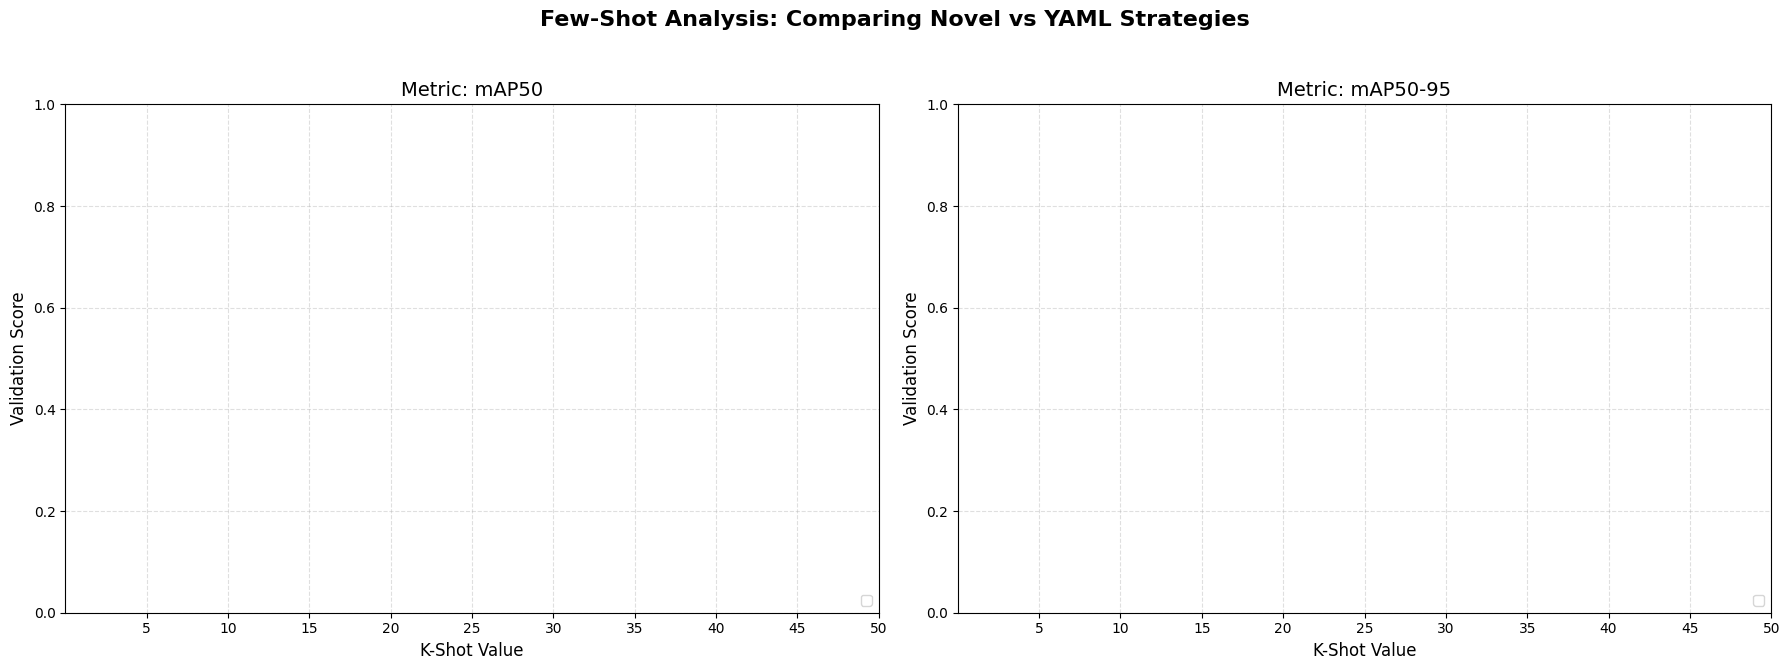

In [13]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- KONFIGURASI ---
results_dir = Path("training_k-shot_results")
shots = list(range(5, 55, 5))
metrics = {"mAP50": "metrics/mAP50(B)", "mAP50-95": "metrics/mAP50-95(B)"}

# Sesuai folder yang Anda berikan: Novel dan yaml
styles = {
    "Novel": {"color": "#1f77b4", "marker": "o", "label": "Novel Class (Base Pre-train)"},
    "yaml":  {"color": "#2ca02c", "marker": "^", "label": "YAML Fine-tuning"}
}

def get_val_metric(strategy, k, col):
    """
    Mengambil metrik dari folder Valid_{Strategy}_class_{k}-shot
    """
    folder_name = f"Valid_{strategy}_class_{k}-shot"
    csv_path = results_dir / folder_name / "results.csv"
    
    if csv_path.exists():
        try:
            print("Ada")
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns] # Bersihkan whitespace pada header
            # Mengambil nilai terakhir dari kolom metrik
            return df[col].iloc[-1]
        except Exception as e:
            print(f"Error pada folder {folder_name}: {e}")
            return 0
    return 0

# --- PROSES PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Few-Shot Analysis: Comparing Novel vs YAML Strategies", fontsize=16, fontweight='bold')

for idx, (m_label, m_col) in enumerate(metrics.items()):
    ax = axes[idx]
    
    for strategy, style in styles.items():
        # Ambil list nilai untuk setiap K (5, 10, ..., 50)
        values = [get_val_metric(strategy, k, m_col) for k in shots]
        
        # Plot garis jika data tersedia
        if any(v > 0 for v in values):
            ax.plot(shots, values, label=style['label'], color=style['color'], 
                    marker=style['marker'], linewidth=2.5, markersize=8)
            
            # Highlight titik tertinggi (Best K)
            max_val = max(values)
            max_idx = values.index(max_val)
            best_k = shots[max_idx]
            
            ax.scatter(best_k, max_val, s=250, facecolors='none', 
                       edgecolors=style['color'], linewidth=2, zorder=5)
            
            # Tambahkan label nilai di titik tertinggi
            ax.text(best_k, max_val + (max_val * 0.02), f"{max_val:.4f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color=style['color'])

    ax.set_title(f"Metric: {m_label}", fontsize=14)
    ax.set_xlabel("K-Shot Value", fontsize=12)
    ax.set_ylabel("Validation Score", fontsize=12)
    ax.set_xticks(shots)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Faster R-CNN

## Untuk split data

In [9]:
import os
import json
import shutil
import random
from collections import defaultdict

def copy_full_folder(source_dir, target_dir):
    """
    Menyalin seluruh isi folder (gambar & json) ke target.
    Digunakan untuk folder 'valid' dan 'test'.
    """
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    
    files = os.listdir(source_dir)
    print(f"    -> Menyalin {len(files)} file dari {os.path.basename(source_dir)} (Full Copy)...")
    
    for f in files:
        src = os.path.join(source_dir, f)
        dst = os.path.join(target_dir, f)
        if os.path.isfile(src):
            shutil.copy2(src, dst)

def process_k_shot_train(source_dir, target_dir, k, json_filename="_annotations.coco.json"):
    """
    Mengambil K sampel per kelas dari folder train, membuat JSON baru, dan copy gambar terpilih.
    """
    source_json = os.path.join(source_dir, json_filename)
    if not os.path.exists(source_json):
        print(f"    [SKIP] JSON tidak ditemukan di {source_dir}")
        return

    # 1. Load JSON
    with open(source_json, 'r') as f:
        data = json.load(f)

    # 2. Grouping Images by Category
    # Map: Category ID -> List of Image IDs
    cat_to_img_ids = defaultdict(set)
    img_id_to_filename = {img['id']: img['file_name'] for img in data['images']}
    
    for ann in data['annotations']:
        cat_to_img_ids[ann['category_id']].add(ann['image_id'])

    # 3. Random Sampling (Fixed Seed)
    # Gunakan seed agar K=10 pasti mengandung gambar yang sama dengan K=5, plus 5 baru.
    random.seed(42) 
    
    selected_image_ids = set()
    print(f"    -> Sampling {k}-Shot untuk Training:")

    for cat_id, img_ids in cat_to_img_ids.items():
        img_list = list(img_ids)
        # Sort dulu sebelum shuffle agar urutan awal selalu sama sebelum diacak
        img_list.sort() 
        random.shuffle(img_list)
        
        # Ambil K teratas
        taken = img_list[:k]
        selected_image_ids.update(taken)
        
        cat_name = next((c['name'] for c in data['categories'] if c['id'] == cat_id), str(cat_id))
        print(f"       - Class '{cat_name}': {len(taken)}/{len(img_list)} gambar diambil")

    # 4. Filter JSON Structure
    new_data = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "categories": data["categories"],
        "images": [],
        "annotations": []
    }

    # Filter Images
    for img in data['images']:
        if img['id'] in selected_image_ids:
            new_data['images'].append(img)

    # Filter Annotations
    for ann in data['annotations']:
        if ann['image_id'] in selected_image_ids:
            new_data['annotations'].append(ann)

    # 5. Write Output
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save JSON
    target_json = os.path.join(target_dir, json_filename)
    with open(target_json, 'w') as f:
        json.dump(new_data, f)
    
    # Copy Selected Images Only
    count_copied = 0
    for img_id in selected_image_ids:
        fname = img_id_to_filename[img_id]
        src_path = os.path.join(source_dir, fname)
        dst_path = os.path.join(target_dir, fname)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
            count_copied += 1
    
    print(f"    -> Selesai. {count_copied} gambar training disalin ke {target_dir}")


def create_splits(root_path, k_values):
    """
    Fungsi Utama Loop K-Values
    """
    subfolders = ['train', 'valid', 'test']
    json_name = "_annotations.coco.json" # Pastikan nama file JSON di Roboflow sesuai ini

    if not os.path.exists(root_path):
        print(f"Error: Folder root '{root_path}' tidak ditemukan.")
        return

    for k in k_values:
        # Nama folder output: faster-r-cnn/5-shot
        output_k_folder = os.path.join(root_path, f"{k}-shot")
        
        print(f"\n==========================================")
        print(f"PROCESSING DATASET: {k}-SHOT")
        print(f"Target: {output_k_folder}")
        print(f"==========================================")
        
        if not os.path.exists(output_k_folder):
            os.makedirs(output_k_folder)

        for sub in subfolders:
            src_sub = os.path.join(root_path, sub) # misal: faster-r-cnn/train
            dst_sub = os.path.join(output_k_folder, sub) # misal: faster-r-cnn/5-shot/train
            
            if not os.path.exists(src_sub):
                print(f"Warning: Subfolder '{sub}' tidak ditemukan di source, skip.")
                continue

            if sub == 'train':
                # LOGIKA KHUSUS TRAIN: Ambil K sampel
                process_k_shot_train(src_sub, dst_sub, k, json_name)
            else:
                # LOGIKA VALID & TEST: Copy Semua
                copy_full_folder(src_sub, dst_sub)

# --- KONFIGURASI ---
# Ganti dengan path folder root 'faster-r-cnn' Anda
# Struktur folder harus:
# ROOT_DIRECTORY/
#    ├── train/ (_annotations.coco.json + images)
#    ├── valid/ (_annotations.coco.json + images)
#    └── test/  (_annotations.coco.json + images)

ROOT_DIRECTORY = "dataset_k-shot/faster-r-cnn" 

# Range K: 5 sampai 50 kelipatan 5
K_RANGE = range(5, 55, 5) 

if __name__ == "__main__":
    create_splits(ROOT_DIRECTORY, K_RANGE)


PROCESSING DATASET: 5-SHOT
Target: dataset_k-shot/faster-r-cnn\5-shot
    -> Sampling 5-Shot untuk Training:
       - Class 'rust': 5/175 gambar diambil
       - Class 'healthy': 5/175 gambar diambil
    -> Selesai. 10 gambar training disalin ke dataset_k-shot/faster-r-cnn\5-shot\train
    -> Menyalin 51 file dari valid (Full Copy)...
    -> Menyalin 101 file dari test (Full Copy)...

PROCESSING DATASET: 10-SHOT
Target: dataset_k-shot/faster-r-cnn\10-shot
    -> Sampling 10-Shot untuk Training:
       - Class 'rust': 10/175 gambar diambil
       - Class 'healthy': 10/175 gambar diambil
    -> Selesai. 20 gambar training disalin ke dataset_k-shot/faster-r-cnn\10-shot\train
    -> Menyalin 51 file dari valid (Full Copy)...
    -> Menyalin 101 file dari test (Full Copy)...

PROCESSING DATASET: 15-SHOT
Target: dataset_k-shot/faster-r-cnn\15-shot
    -> Sampling 15-Shot untuk Training:
       - Class 'rust': 15/175 gambar diambil
       - Class 'healthy': 15/175 gambar diambil
    -> Seles

## Training

In [18]:
# === CELL 1: SETUP & BASE TRAINING WITH mAP ===
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
import os
import pandas as pd
import numpy as np
import time

# --- 1. CONFIGURATION ---
BASE_DATA_DIR = "dataset_k-shot/healthy" # Pastikan di dalamnya ada 'train' dan 'valid'
OUTPUT_BASE_DIR = "fast-r-cnn_results/base_class"
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
BATCH_SIZE = 4
EPOCHS_BASE = 15  # Disarankan minimal 20-50 untuk Base Training

os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)

# --- 2. DATASET CLASS ---
class CocoCustomDataset(Dataset):
    def __init__(self, root_dir, type_dir, transforms=None):
        self.full_path = os.path.join(root_dir, type_dir)
        
        # Cek apakah folder ada
        if not os.path.exists(self.full_path):
            raise FileNotFoundError(f"Folder {type_dir} tidak ditemukan di {root_dir}")

        # Cari file json otomatis
        json_files = [f for f in os.listdir(self.full_path) if f.endswith('.json')]
        if not json_files:
            raise FileNotFoundError(f"Tidak ada file .json di {self.full_path}")
            
        self.coco = COCO(os.path.join(self.full_path, json_files[0]))
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms
        
        # Mapping Category ID
        cats = self.coco.loadCats(self.coco.getCatIds())
        self.cat_id_map = {cat['id']: i+1 for i, cat in enumerate(cats)}
        self.num_classes = len(cats)

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        coco_annotation = coco.loadAnns(ann_ids)
        
        img_info = coco.loadImgs(img_id)[0]
        path = img_info['file_name']
        img_path = os.path.join(self.full_path, path)
        
        img = Image.open(img_path).convert("RGB")
        img = torchvision.transforms.functional.to_tensor(img)

        boxes = []
        labels = []
        for ann in coco_annotation:
            xmin, ymin, w, h = ann['bbox']
            # Convert ke x1, y1, x2, y2
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(self.cat_id_map[ann['category_id']])

        target = {}
        target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        target["labels"] = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        target["image_id"] = torch.tensor([img_id])
        target["area"] = torch.as_tensor([ann['area'] for ann in coco_annotation], dtype=torch.float32) if boxes else torch.zeros((0,), dtype=torch.float32)
        target["iscrowd"] = torch.as_tensor([ann['iscrowd'] for ann in coco_annotation], dtype=torch.int64) if boxes else torch.zeros((0,), dtype=torch.int64)

        return img, target

    def __len__(self):
        return len(self.ids)

def collate_fn(batch):
    return tuple(zip(*batch))

# --- 3. EVALUATION FUNCTION (mAP) ---
@torch.no_grad()
def evaluate_map(model, data_loader, device):
    n_threads = torch.get_num_threads()
    torch.set_num_threads(1)
    cpu_device = torch.device("cpu")
    model.eval()
    
    coco = data_loader.dataset.coco
    
    # --- PERBAIKAN: BUAT INVERSE MAPPING ---
    # Kita butuh peta: ID Model (1,2,3) -> ID Asli JSON (0, 15, 80, dll)
    # Ambil map dari dataset
    model_id_to_json_id = {v: k for k, v in data_loader.dataset.cat_id_map.items()}
    
    coco_results = []
    print("\n  -> Debugging Prediction Sample:")
    
    debug_count = 0
    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)
        outputs = [{k: v.to(cpu_device) for k, v in t.items()} for t in outputs]
        
        for target, output in zip(targets, outputs):
            image_id = target["image_id"].item()
            boxes = output["boxes"].tolist()
            scores = output["scores"].tolist()
            labels = output["labels"].tolist()
            
            # DEBUG: Print 1 sampel prediksi pertama untuk cek
            if debug_count == 0 and len(boxes) > 0:
                print(f"     GT Label ID (Internal): {target['labels'].tolist()}")
                print(f"     Pred Label ID (Model): {labels}")
                print(f"     Pred Score: {scores[0]:.4f}")
                print(f"     Pred Box: {boxes[0]}")
                debug_count += 1
            
            for i in range(len(boxes)):
                xmin, ymin, xmax, ymax = boxes[i]
                
                # --- FIX 1: KEMBALIKAN KE ID ASLI JSON ---
                model_label_id = labels[i]
                original_coco_id = model_id_to_json_id.get(model_label_id, model_label_id)
                
                res = {
                    "image_id": image_id,
                    "category_id": original_coco_id, # PENTING: Pakai ID asli JSON
                    "bbox": [xmin, ymin, xmax - xmin, ymax - ymin], # x,y,w,h
                    "score": scores[i]
                }
                coco_results.append(res)
                
    stats = [0, 0]
    if len(coco_results) > 0:
        coco_dt = coco.loadRes(coco_results)
        coco_eval = COCOeval(coco, coco_dt, "bbox")
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        stats = coco_eval.stats
    else:
        print("  [WARNING] Tidak ada prediksi bounding box sama sekali!")
        
    torch.set_num_threads(n_threads)
    return stats[1], stats[0]

# --- 4. MODEL BUILDER ---
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    return model

# --- 5. TRAINING FUNCTION ---
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    count = 0
    for images, targets in loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        count += 1
    return total_loss / count if count > 0 else 0

# --- 6. EXECUTION ---
print("=== STARTING BASE TRAINING (WITH mAP) ===")

# A. Setup Data
print("Loading Datasets...")
ds_train = CocoCustomDataset(BASE_DATA_DIR, 'train')
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# Cek apakah ada folder valid, jika tidak pakai train (split manual) atau test
val_type = 'valid' if os.path.exists(os.path.join(BASE_DATA_DIR, 'valid')) else 'test'
if not os.path.exists(os.path.join(BASE_DATA_DIR, val_type)):
    print("Warning: Folder 'valid' atau 'test' tidak ditemukan. Evaluasi mAP akan menggunakan data TRAIN (Bias).")
    val_type = 'train'

ds_val = CocoCustomDataset(BASE_DATA_DIR, val_type)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Base Dataset: {ds_train.num_classes} classes detected.")
print(f"Training on {len(ds_train)} images, Validating on {len(ds_val)} images ({val_type}).")

# B. Setup Model
model = get_model(ds_train.num_classes)
model.to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# C. Loop
history = []
for epoch in range(EPOCHS_BASE):
    start_time = time.time()
    
    # 1. Training
    loss = train_one_epoch(model, dl_train, optimizer, DEVICE)
    
    # 2. Evaluation
    print(f"Epoch {epoch+1}/{EPOCHS_BASE} | Loss: {loss:.4f} | Evaluating mAP...", end="\r")
    map50, map95 = evaluate_map(model, dl_val, DEVICE)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS_BASE} | Loss: {loss:.4f} | mAP50: {map50:.4f} | mAP95: {map95:.4f} | Time: {elapsed:.0f}s")
    
    history.append({
        'epoch': epoch+1, 
        'loss': loss, 
        'mAP50': map50, 
        'mAP50-95': map95
    })

# D. Save Results
print("Saving model and results...")
torch.save(model.state_dict(), os.path.join(OUTPUT_BASE_DIR, "base_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(OUTPUT_BASE_DIR, "results.csv"), index=False)
print("Base Training Completed.")

=== STARTING BASE TRAINING (WITH mAP) ===
Loading Datasets...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Base Dataset: 2 classes detected.
Training on 175 images, Validating on 25 images (valid).
Epoch 1/15 | Loss: 0.5209 | Evaluating mAP...
  -> Debugging Prediction Sample:
     GT Label ID (Internal): [2, 2, 2]
     Pred Label ID (Model): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
     Pred Score: 0.9809
     Pred Box: [6.361377239227295, 452.9605407714844, 140.03526306152344, 630.3370971679688]
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.611
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.910
 Average Pr

In [19]:
# === CELL 2: NOVEL FINE-TUNING LOOP (5-50 SHOT) WITH mAP ===
import torch
import copy
import time
from pycocotools.cocoeval import COCOeval
import numpy as np

# --- CONFIGURATION ---
ROOT_NOVEL_DIR = "dataset_k-shot/faster-r-cnn" 
OUTPUT_ROOT_DIR = "fast-r-cnn_results"
BASE_WEIGHT_PATH = os.path.join(OUTPUT_BASE_DIR, "base_model.pth")
K_VALUES = range(5, 55, 5) # 5, 10 ... 50
EPOCHS_NOVEL = 20          # Epoch training

# --- FUNGSI EVALUASI mAP (COCO STYLE) ---
@torch.no_grad()
def evaluate_map(model, data_loader, device):
    n_threads = torch.get_num_threads()
    torch.set_num_threads(1)
    cpu_device = torch.device("cpu")
    model.eval()
    
    coco = data_loader.dataset.coco
    
    # --- PERBAIKAN: BUAT INVERSE MAPPING ---
    # Kita butuh peta: ID Model (1,2,3) -> ID Asli JSON (0, 15, 80, dll)
    # Ambil map dari dataset
    model_id_to_json_id = {v: k for k, v in data_loader.dataset.cat_id_map.items()}
    
    coco_results = []
    print("\n  -> Debugging Prediction Sample:")
    
    debug_count = 0
    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)
        outputs = [{k: v.to(cpu_device) for k, v in t.items()} for t in outputs]
        
        for target, output in zip(targets, outputs):
            image_id = target["image_id"].item()
            boxes = output["boxes"].tolist()
            scores = output["scores"].tolist()
            labels = output["labels"].tolist()
            
            # DEBUG: Print 1 sampel prediksi pertama untuk cek
            if debug_count == 0 and len(boxes) > 0:
                print(f"     GT Label ID (Internal): {target['labels'].tolist()}")
                print(f"     Pred Label ID (Model): {labels}")
                print(f"     Pred Score: {scores[0]:.4f}")
                print(f"     Pred Box: {boxes[0]}")
                debug_count += 1
            
            for i in range(len(boxes)):
                xmin, ymin, xmax, ymax = boxes[i]
                
                # --- FIX 1: KEMBALIKAN KE ID ASLI JSON ---
                model_label_id = labels[i]
                original_coco_id = model_id_to_json_id.get(model_label_id, model_label_id)
                
                res = {
                    "image_id": image_id,
                    "category_id": original_coco_id, # PENTING: Pakai ID asli JSON
                    "bbox": [xmin, ymin, xmax - xmin, ymax - ymin], # x,y,w,h
                    "score": scores[i]
                }
                coco_results.append(res)
                
    stats = [0, 0]
    if len(coco_results) > 0:
        coco_dt = coco.loadRes(coco_results)
        coco_eval = COCOeval(coco, coco_dt, "bbox")
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        stats = coco_eval.stats
    else:
        print("  [WARNING] Tidak ada prediksi bounding box sama sekali!")
        
    torch.set_num_threads(n_threads)
    return stats[1], stats[0]
# --- MAIN LOOP ---
print("=== STARTING K-SHOT FINE-TUNING LOOP ===")

for k in K_VALUES:
    shot_folder = f"{k}-shot"
    data_path = os.path.join(ROOT_NOVEL_DIR, shot_folder)
    output_dir = os.path.join(OUTPUT_ROOT_DIR, f"novel_{k}-shot")
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n========================================")
    print(f"Processing K={k} Shot")
    print(f"========================================")
    
    # 1. Setup Dataset Train & Test
    try:
        ds_train = CocoCustomDataset(data_path, 'train')
        dl_train = DataLoader(ds_train, batch_size=2, shuffle=True, collate_fn=collate_fn)
        
        # Load Test set untuk hitung mAP
        ds_test = CocoCustomDataset(data_path, 'test')
        dl_test = DataLoader(ds_test, batch_size=2, shuffle=False, collate_fn=collate_fn)
    except Exception as e:
        print(f"Skipping K={k}, error loading data: {e}")
        continue

    # 2. Setup Model & Load Base Weights
    model = get_model(ds_train.num_classes)
    
    # Load Base Weights
    if os.path.exists(BASE_WEIGHT_PATH):
        base_state = torch.load(BASE_WEIGHT_PATH)
        model_state = model.state_dict()
        pretrained_dict = {k: v for k, v in base_state.items() if k in model_state and v.size() == model_state[k].size()}
        model_state.update(pretrained_dict)
        model.load_state_dict(model_state)
    else:
        print("Warning: Base model weights not found! Training from scratch.")
    
    model.to(DEVICE)
    
    # 3. Freeze Backbone
    for name, param in model.named_parameters():
        if "roi_heads" not in name: 
            param.requires_grad = False
            
    # 4. Optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9)
    
    # 5. Training Loop
    history = []
    final_map50 = 0
    final_map95 = 0
    
    for epoch in range(EPOCHS_NOVEL):
        loss = train_one_epoch(model, dl_train, optimizer, DEVICE)
        
        print(f"  Epoch {epoch+1}/{EPOCHS_NOVEL} | Loss: {loss:.4f}")
        history.append({'epoch': epoch+1, 'train_loss': loss})
    
    # 6. Evaluasi mAP (Hanya di akhir training agar hemat waktu)
    print(f"  -> Training selesai. Menghitung mAP untuk K={k}...")
    final_map50, final_map95 = evaluate_map(model, dl_test, DEVICE)
    
    # Tambahkan mAP ke baris terakhir history agar tersimpan di CSV
    history[-1]['mAP50'] = final_map50
    history[-1]['mAP50-95'] = final_map95
    
    print(f"  -> Result K={k}: mAP50 = {final_map50:.4f}, mAP50-95 = {final_map95:.4f}")

    # 7. Save Result & Model
    # Simpan CSV
    df_res = pd.DataFrame(history)
    df_res.to_csv(os.path.join(output_dir, "results.csv"), index=False)
    
    # Simpan Model (.pth) - INI YANG ANDA MINTA UTK VISUALISASI
    model_save_path = os.path.join(output_dir, "model_final.pth")
    torch.save(model.state_dict(), model_save_path)
    print(f"  -> Model saved to: {model_save_path}")

print("\nSemua Training Selesai.")

=== STARTING K-SHOT FINE-TUNING LOOP ===

Processing K=5 Shot
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
  Epoch 1/20 | Loss: 1.1937
  Epoch 2/20 | Loss: 0.4836
  Epoch 3/20 | Loss: 0.4670
  Epoch 4/20 | Loss: 0.4593
  Epoch 5/20 | Loss: 0.4239
  Epoch 6/20 | Loss: 0.3951
  Epoch 7/20 | Loss: 0.3553
  Epoch 8/20 | Loss: 0.3340
  Epoch 9/20 | Loss: 0.3064
  Epoch 10/20 | Loss: 0.2913
  Epoch 11/20 | Loss: 0.2795
  Epoch 12/20 | Loss: 0.2566
  Epoch 13/20 | Loss: 0.2417
  Epoch 14/20 | Loss: 0.2296
  Epoch 15/20 | Loss: 0.2066
  Epoch 16/20 | Loss: 0.1951
  Epoch 17/20 | Loss: 0.1832
  Epoch 18/20 | Loss: 0.1761
  Epoch 19/20 | Loss: 0.1704
  Epoch 20/20 | Loss: 0.1624
  -> Training selesai. Menghitung mAP untuk K=5...

  -> Debugging Prediction Sample:
     GT Label ID (Internal): [3]
     Pred Label ID (Model): [2, 2, 2, 3, 3, 3]
     Pred Score: 0.8675
     Pred B

Mengumpulkan data mAP dari hasil training...


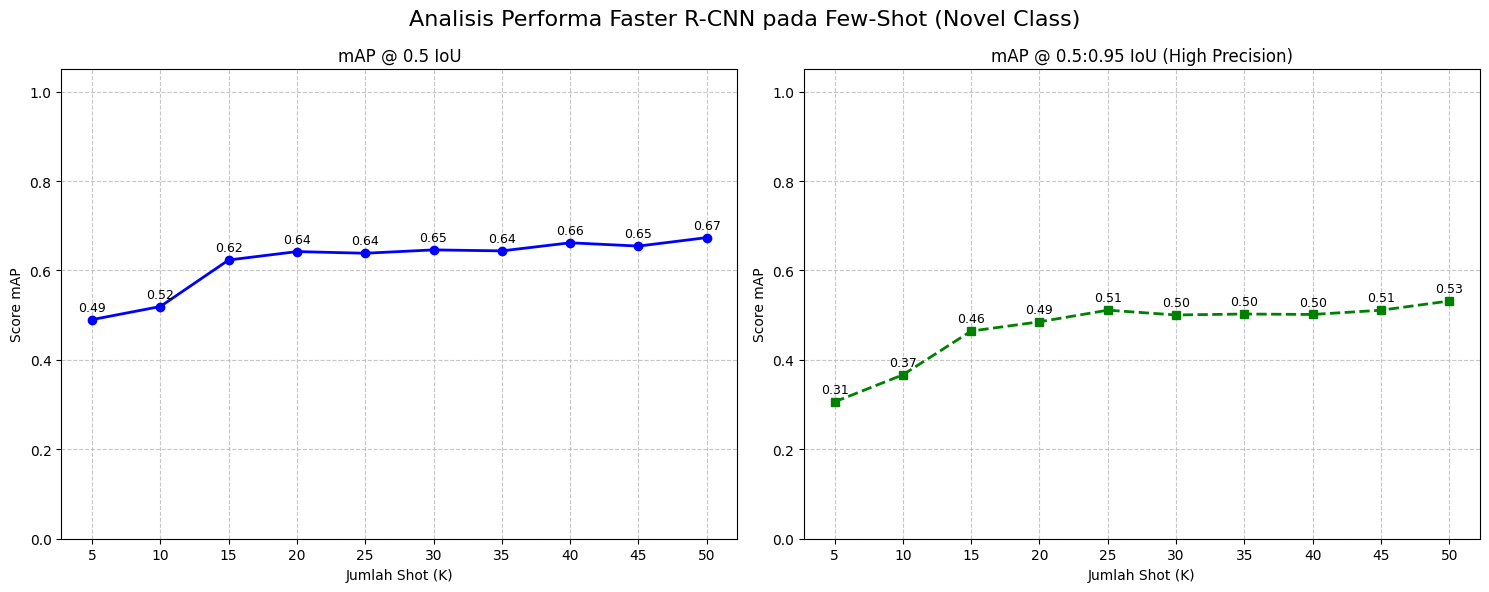


=== Detail Data Evaluasi ===
 K-Shot    mAP50  mAP50-95
      5 0.490064  0.306031
     10 0.519443  0.366581
     15 0.623490  0.464492
     20 0.642286  0.485237
     25 0.638608  0.511248
     30 0.646124  0.500516
     35 0.643862  0.502641
     40 0.661977  0.501670
     45 0.654634  0.511139
     50 0.673580  0.531758


In [20]:
# === CELL 3: COMPARISON PLOT (mAP vs K-Shot) ===
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- KONFIGURASI ---
OUTPUT_ROOT_DIR = "fast-r-cnn_results"
K_VALUES = range(5, 55, 5) # 5, 10 ... 50

# List penampung data
valid_k = []
map50_values = []
map95_values = []

print("Mengumpulkan data mAP dari hasil training...")

for k in K_VALUES:
    csv_path = os.path.join(OUTPUT_ROOT_DIR, f"novel_{k}-shot", "results.csv")
    
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            
            # Pastikan kolom mAP ada (karena versi lama mungkin belum ada)
            if 'mAP50' in df.columns and 'mAP50-95' in df.columns:
                # Ambil nilai terakhir (evaluasi final)
                last_row = df.iloc[-1]
                
                # Cek jika nilai valid (bukan NaN atau 0 jika training gagal)
                m50 = float(last_row['mAP50'])
                m95 = float(last_row['mAP50-95'])
                
                valid_k.append(k)
                map50_values.append(m50)
                map95_values.append(m95)
            else:
                print(f"Warning: Kolom mAP tidak ditemukan di K={k}")
                
        except Exception as e:
            print(f"Error membaca K={k}: {e}")
    else:
        print(f"Info: Hasil training untuk K={k} belum tersedia.")

# --- PLOTTING ---
if not valid_k:
    print("Tidak ada data mAP yang bisa ditampilkan. Pastikan Training Cell 2 sudah selesai.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Analisis Performa Faster R-CNN pada Few-Shot (Novel Class)', fontsize=16)

    # 1. Plot mAP50
    ax1.plot(valid_k, map50_values, marker='o', linestyle='-', color='blue', linewidth=2, label='Faster R-CNN')
    ax1.set_title('mAP @ 0.5 IoU')
    ax1.set_xlabel('Jumlah Shot (K)')
    ax1.set_ylabel('Score mAP')
    ax1.set_ylim(0, 1.05) # Batas Y 0 sampai 1
    ax1.set_xticks(valid_k)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Annotasi nilai di titik
    for x, y in zip(valid_k, map50_values):
        ax1.text(x, y + 0.02, f"{y:.2f}", ha='center', fontsize=9)

    # 2. Plot mAP50-95
    ax2.plot(valid_k, map95_values, marker='s', linestyle='--', color='green', linewidth=2, label='Faster R-CNN')
    ax2.set_title('mAP @ 0.5:0.95 IoU (High Precision)')
    ax2.set_xlabel('Jumlah Shot (K)')
    ax2.set_ylabel('Score mAP')
    ax2.set_ylim(0, 1.05)
    ax2.set_xticks(valid_k)
    ax2.grid(True, linestyle='--', alpha=0.7)

    # Annotasi nilai di titik
    for x, y in zip(valid_k, map95_values):
        ax2.text(x, y + 0.02, f"{y:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Tampilkan Tabel Data
    print("\n=== Detail Data Evaluasi ===")
    df_compare = pd.DataFrame({
        'K-Shot': valid_k,
        'mAP50': map50_values,
        'mAP50-95': map95_values
    })
    print(df_compare.to_string(index=False))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Detected Classes: {1: 'leaf-KlzY', 2: 'healthy', 3: 'rust'}

Menampilkan hasil visualisasi...


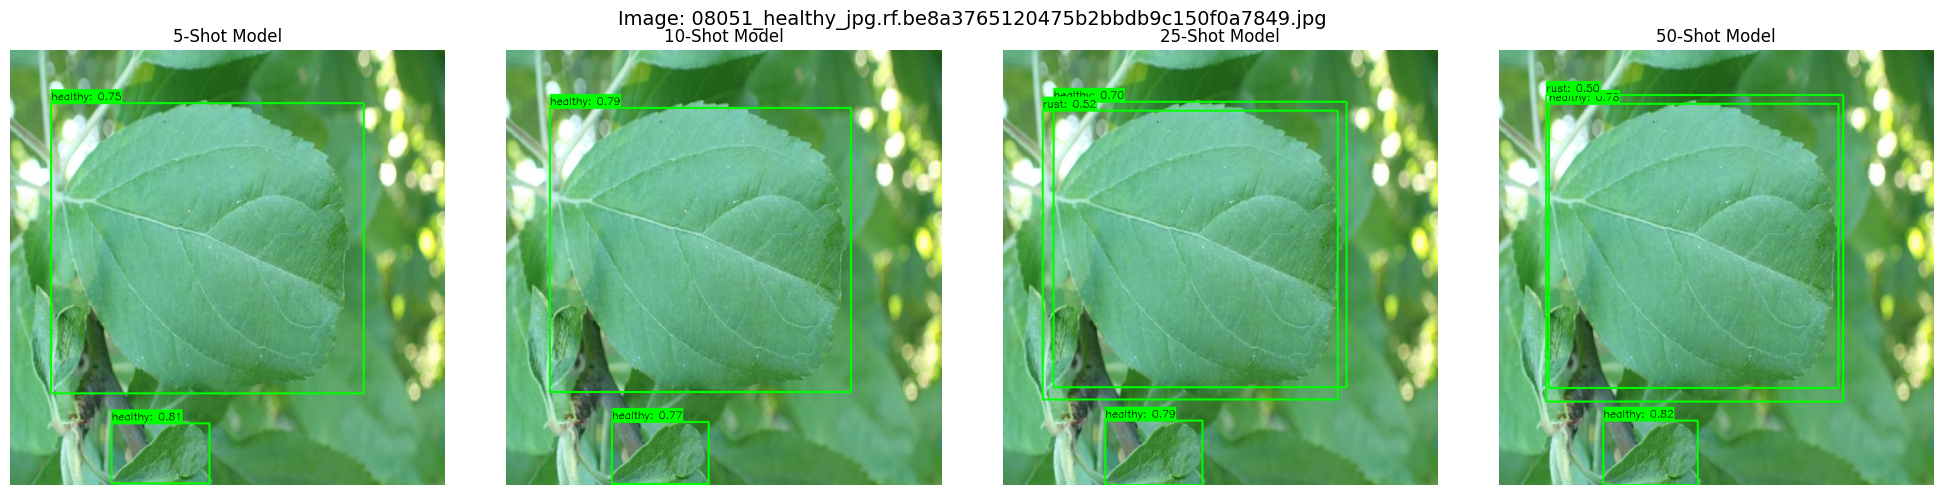

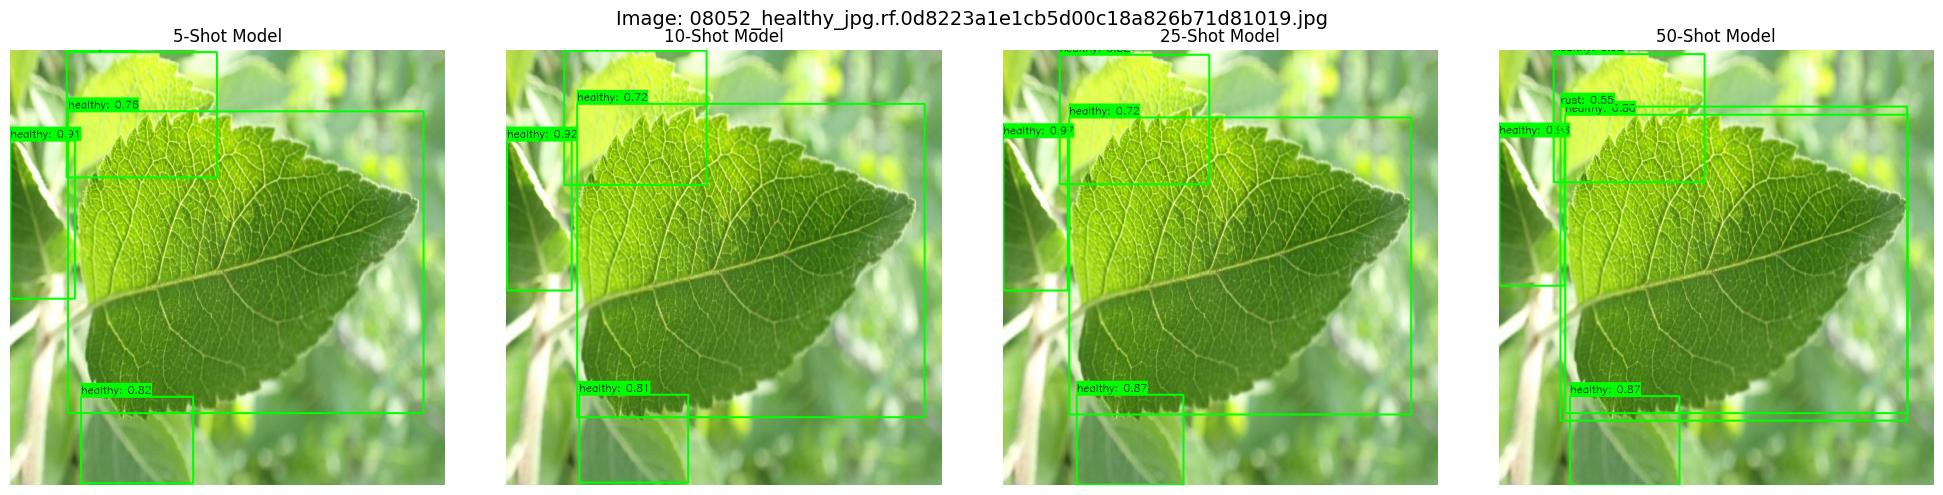

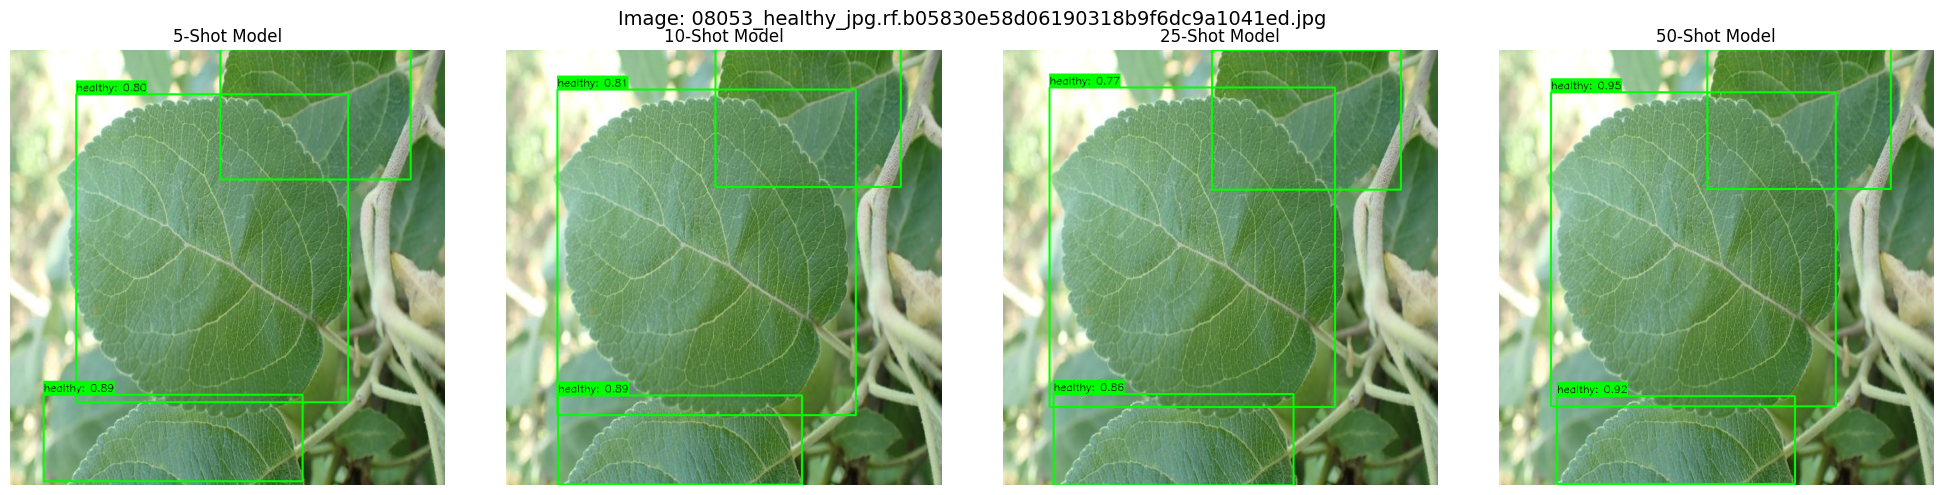

In [28]:
# === CELL 4: VISUALISASI HASIL PREDIKSI (BOUNDING BOX) ===
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

# ==========================================
# 1. KONFIGURASI
# ==========================================
# Folder tempat gambar Test berada (Ambil dari salah satu K-shot)
TEST_IMAGES_DIR = "dataset_k-shot/faster-r-cnn/5-shot/test" 
# File JSON Anotasi (untuk mengambil nama kelas)
ANNOTATION_FILE = "dataset_k-shot/faster-r-cnn/5-shot/test/_annotations.coco.json"

# Folder tempat hasil training disimpan
RESULTS_DIR = "fast-r-cnn_results"

# Pilih K berapa saja yang ingin dibandingkan
K_TO_COMPARE = [5, 10, 25, 50] 

# Jumlah gambar tes yang ingin ditampilkan
NUM_IMAGES_TO_SHOW = 3 

# Threshold score (hanya tampilkan box di atas keyakinan ini)
CONFIDENCE_THRESHOLD = 0.5 

# Setup Device
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# ==========================================
# 2. FUNGSI UTILITAS
# ==========================================
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    return model

def draw_boxes(img_tensor, prediction, label_map, threshold=0.5):
    """
    Menggambar kotak dan nama kelas pada gambar.
    """
    img_np = img_tensor.mul(255).permute(1, 2, 0).byte().cpu().numpy()
    img_np = img_np.copy()
    
    boxes = prediction[0]['boxes'].cpu().detach().numpy()
    scores = prediction[0]['scores'].cpu().detach().numpy()
    labels = prediction[0]['labels'].cpu().detach().numpy()
    
    for i, box in enumerate(boxes):
        if scores[i] >= threshold:
            x1, y1, x2, y2 = box.astype(int)
            score = scores[i]
            label_id = labels[i]
            
            # Ambil nama kelas dari label_map
            class_name = label_map.get(label_id, str(label_id))
            
            # Gambar Kotak (Hijau)
            cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Tulis Label & Score
            text = f"{class_name}: {score:.2f}"
            
            # Background text agar terbaca
            (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img_np, (x1, y1 - 20), (x1 + w, y1), (0, 255, 0), -1)
            cv2.putText(img_np, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            
    return img_np

# ==========================================
# 3. PERSIAPAN NAMA KELAS
# ==========================================
# Load JSON untuk mendapatkan mapping ID -> Nama Kelas
try:
    coco = COCO(ANNOTATION_FILE)
    cats = coco.loadCats(coco.getCatIds())
    # Kita replicate logika mapping di Dataset:
    # Model ID dimulai dari 1, urut sesuai list categories di JSON
    label_map = {i+1: cat['name'] for i, cat in enumerate(cats)}
    NUM_CLASSES = len(cats)
    print(f"Detected Classes: {label_map}")
except Exception as e:
    print(f"Warning: Gagal load JSON ({e}). Menggunakan default ID.")
    NUM_CLASSES = 1
    label_map = {}

# ==========================================
# 4. EKSEKUSI VISUALISASI
# ==========================================
# Ambil gambar random
all_test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
if len(all_test_images) == 0:
    print("Error: Tidak ada gambar di folder test!")
else:
    # Ambil 3 gambar pertama (atau bisa diacak pakai random.sample)
    selected_images = sorted(all_test_images)[:NUM_IMAGES_TO_SHOW] 

    print(f"\nMenampilkan hasil visualisasi...")

    for img_name in selected_images:
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)
        
        # Load Image
        img_pil = Image.open(img_path).convert("RGB")
        img_tensor = torchvision.transforms.functional.to_tensor(img_pil).to(DEVICE)
        
        # Setup Plot
        fig, axs = plt.subplots(1, len(K_TO_COMPARE), figsize=(5 * len(K_TO_COMPARE), 5))
        if len(K_TO_COMPARE) == 1: axs = [axs]
        
        fig.suptitle(f"Image: {img_name}", fontsize=14)

        for i, k in enumerate(K_TO_COMPARE):
            # Load Model .pth
            model_path_pth = os.path.join(RESULTS_DIR, f"novel_{k}-shot", "model_final.pth")
            
            if not os.path.exists(model_path_pth):
                # Tampilkan pesan jika model belum ada
                axs[i].text(0.5, 0.5, f"Model K={k}\nNot Found", ha='center', va='center')
                axs[i].axis('off')
                continue
                
            # Init & Load Model
            model = get_model(NUM_CLASSES)
            try:
                model.load_state_dict(torch.load(model_path_pth, map_location=DEVICE))
                model.to(DEVICE)
                model.eval()
                
                # Inference
                with torch.no_grad():
                    prediction = model([img_tensor])
                    
                # Draw Result
                result_img = draw_boxes(img_tensor, prediction, label_map, threshold=CONFIDENCE_THRESHOLD)
                
                # Show
                axs[i].imshow(result_img)
                axs[i].set_title(f"{k}-Shot Model")
                axs[i].axis('off')
                
            except Exception as e:
                axs[i].text(0.5, 0.5, f"Error K={k}\n{str(e)}", ha='center', va='center', fontsize=8)
                axs[i].axis('off')

        plt.tight_layout()
        plt.show()


Menampilkan hasil visualisasi untuk 2 gambar target...


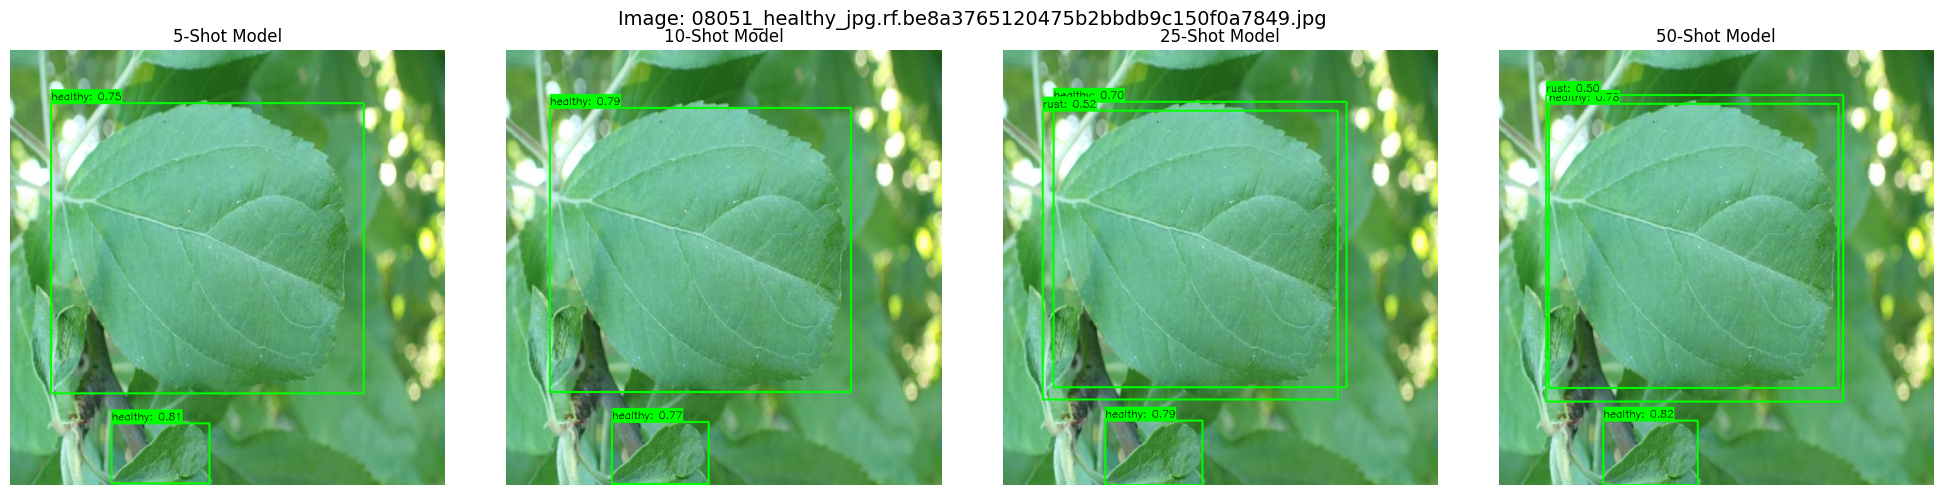

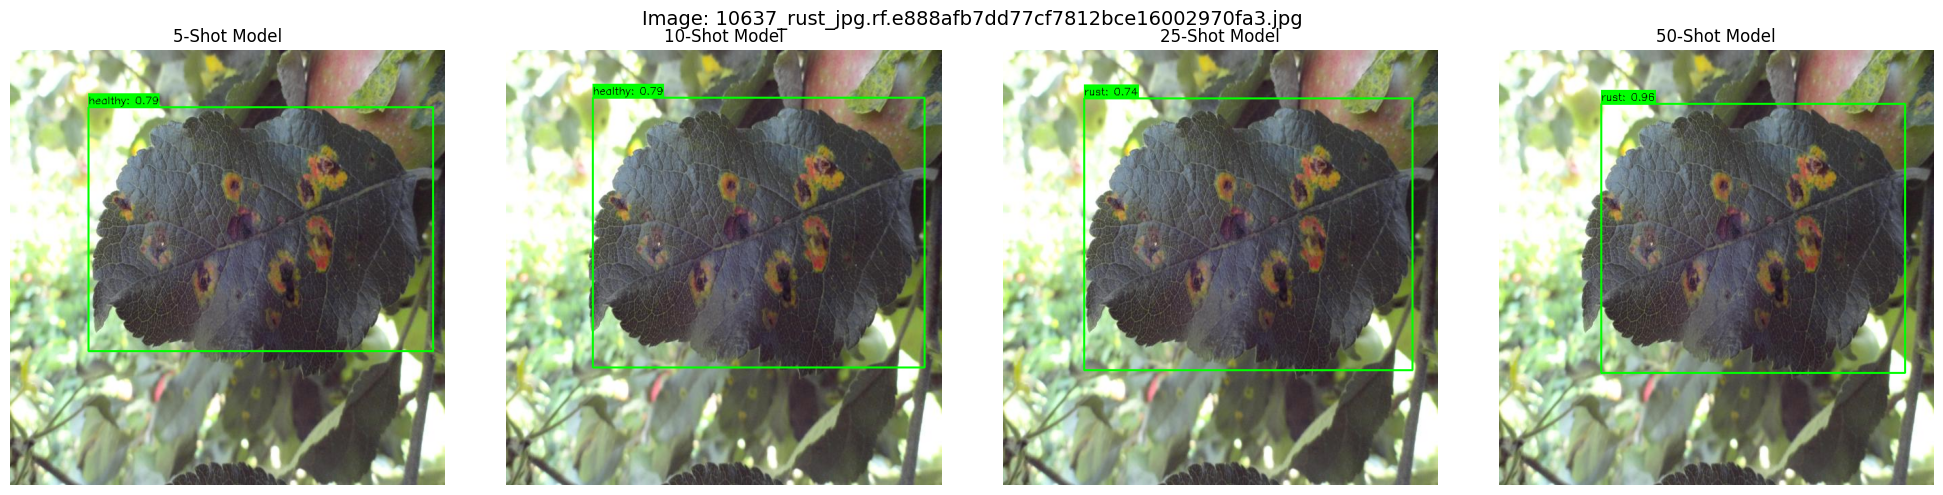

In [29]:
# ==========================================
# 4. EKSEKUSI VISUALISASI (HANYA 2 FILE)
# ==========================================

TARGET_IMAGES = [
    "08051_healthy_jpg.rf.be8a3765120475b2bbdb9c150f0a7849.jpg",
    "10637_rust_jpg.rf.e888afb7dd77cf7812bce16002970fa3.jpg",
]

# Cek apakah file ada
missing = [f for f in TARGET_IMAGES if not os.path.exists(os.path.join(TEST_IMAGES_DIR, f))]
if missing:
    print("Error: File berikut tidak ditemukan di TEST_IMAGES_DIR:")
    for f in missing:
        print("-", os.path.join(TEST_IMAGES_DIR, f))
else:
    selected_images = TARGET_IMAGES

    print(f"\nMenampilkan hasil visualisasi untuk 2 gambar target...")

    for img_name in selected_images:
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)

        # Load Image
        img_pil = Image.open(img_path).convert("RGB")
        img_tensor = torchvision.transforms.functional.to_tensor(img_pil).to(DEVICE)

        # Setup Plot
        fig, axs = plt.subplots(1, len(K_TO_COMPARE), figsize=(5 * len(K_TO_COMPARE), 5))
        if len(K_TO_COMPARE) == 1:
            axs = [axs]

        fig.suptitle(f"Image: {img_name}", fontsize=14)

        for i, k in enumerate(K_TO_COMPARE):
            # Load Model .pth
            model_path_pth = os.path.join(RESULTS_DIR, f"novel_{k}-shot", "model_final.pth")

            if not os.path.exists(model_path_pth):
                axs[i].text(0.5, 0.5, f"Model K={k}\nNot Found", ha='center', va='center')
                axs[i].axis('off')
                continue

            # Init & Load Model
            model = get_model(NUM_CLASSES)
            try:
                model.load_state_dict(torch.load(model_path_pth, map_location=DEVICE))
                model.to(DEVICE)
                model.eval()

                # Inference
                with torch.no_grad():
                    prediction = model([img_tensor])

                # Draw Result
                result_img = draw_boxes(img_tensor, prediction, label_map, threshold=CONFIDENCE_THRESHOLD)

                # Show
                axs[i].imshow(result_img)
                axs[i].set_title(f"{k}-Shot Model")
                axs[i].axis('off')

            except Exception as e:
                axs[i].text(0.5, 0.5, f"Error K={k}\n{str(e)}", ha='center', va='center', fontsize=8)
                axs[i].axis('off')

        plt.tight_layout()
        plt.show()


In [2]:
from ultralytics import YOLO, settings
settings.update({"mlflow": False})

model = YOLO("YOLO12n.pt")
model.train(data="../dataset_collection/roboflow/k-shot/object_detection_all_class/10-shot.yaml", epochs=10, project="DeleteMe", name="YOLO12n_test")

Ultralytics 8.3.243  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/k-shot/object_detection_all_class/10-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=YOLO12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=YOLO12n_test2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000209A4C78200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          